In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("C:/AEGIS/roadmap/Traditional_ML/day_03/data/bank_marketing.csv")
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,210,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,138,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,339,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,185,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,137,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,59,retired,married,high.school,unknown,no,yes,telephone,jun,thu,222,1,999,0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,0
41184,31,housemaid,married,basic.4y,unknown,no,no,telephone,may,thu,196,2,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0
41185,42,admin.,single,university.degree,unknown,yes,yes,telephone,may,wed,62,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
41186,48,technician,married,professional.course,no,no,yes,telephone,oct,tue,200,2,999,0,nonexistent,-3.4,92.431,-26.9,0.742,5017.5,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null  float64
 1

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [6]:
num_col= list(df.select_dtypes(include = 'number').columns)
num_col

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp_var_rate',
 'cons_price_idx',
 'cons_conf_idx',
 'euribor3m',
 'nr_employed',
 'y']

In [7]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(12)

In [9]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

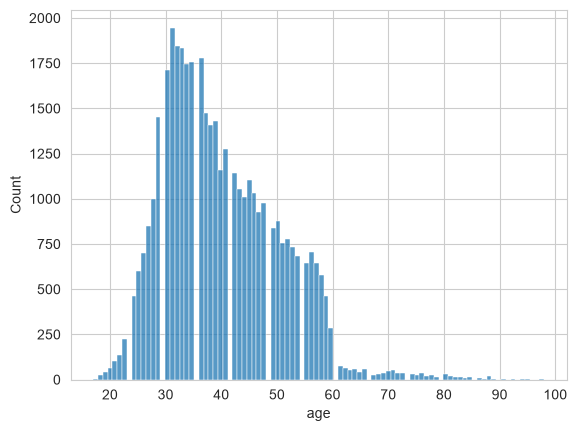

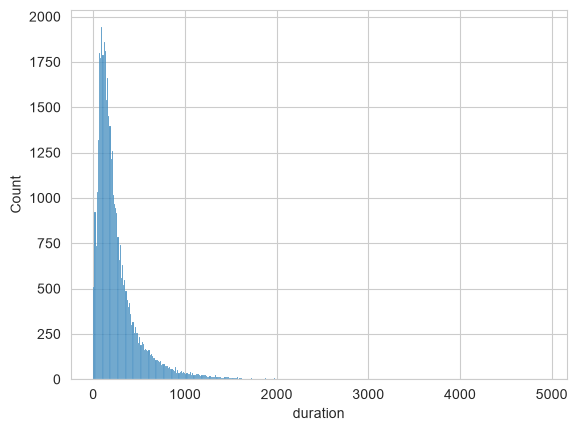

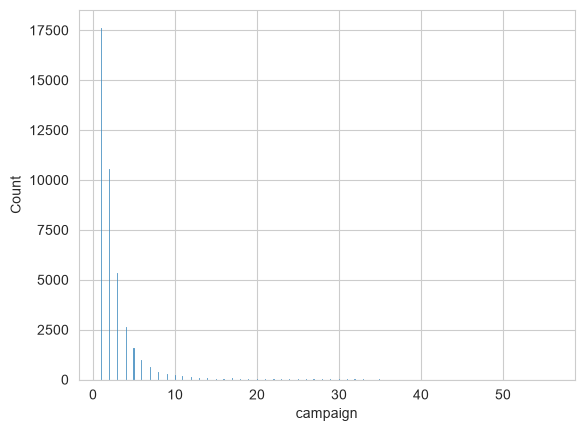

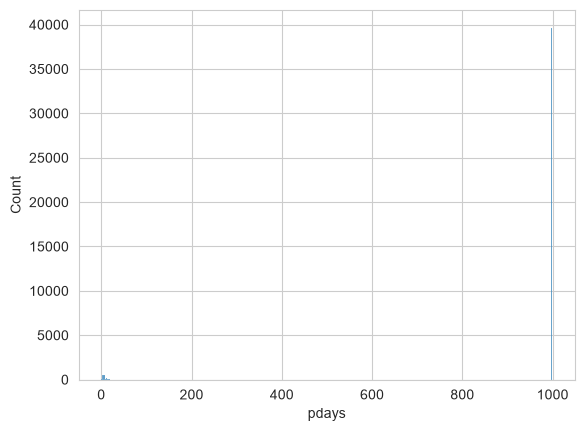

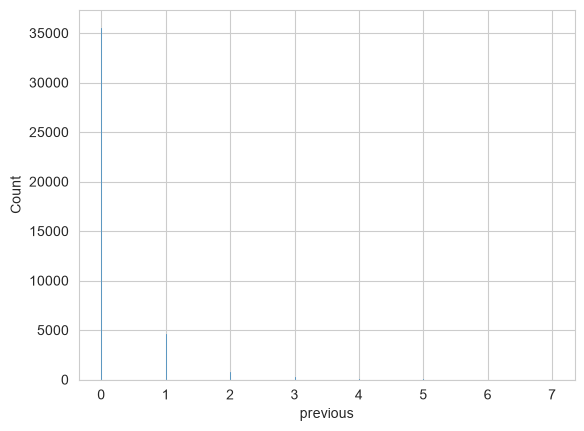

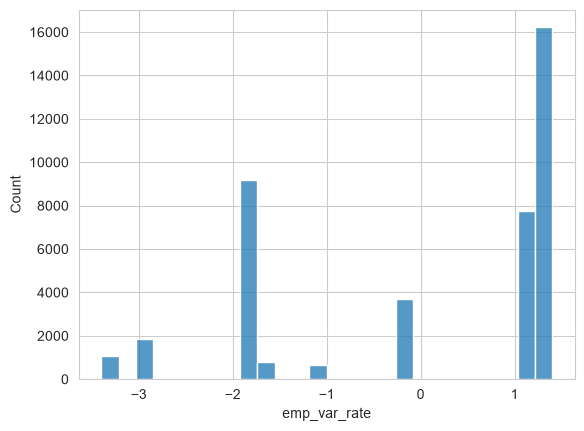

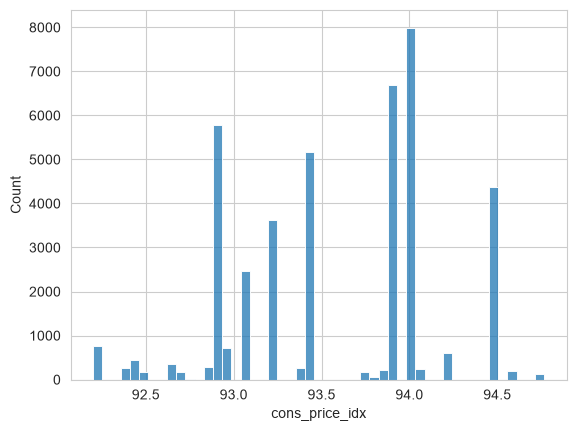

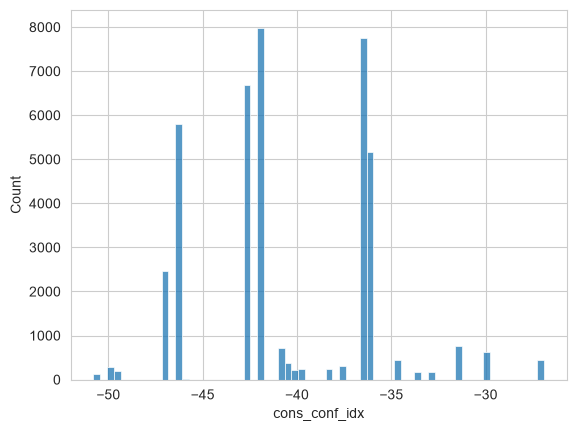

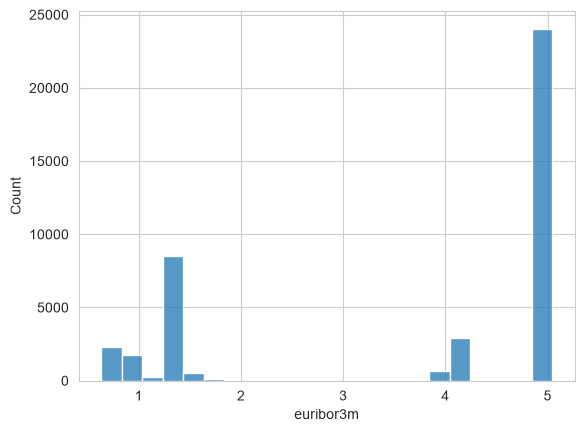

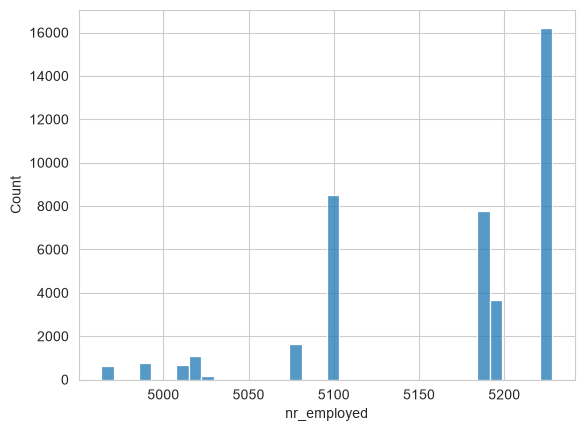

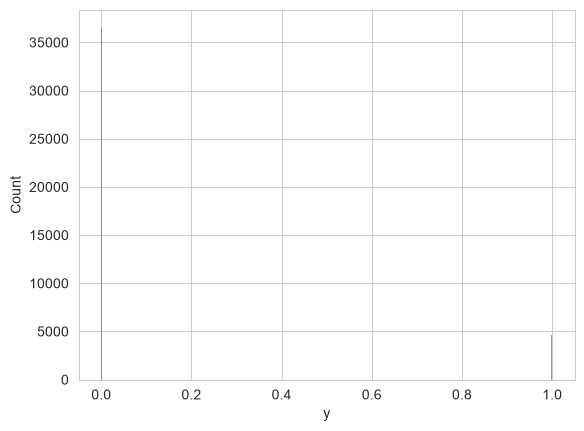

In [10]:
for col in num_col:
    sns.histplot(df[col])
    plt.show()

<Axes: xlabel='y'>

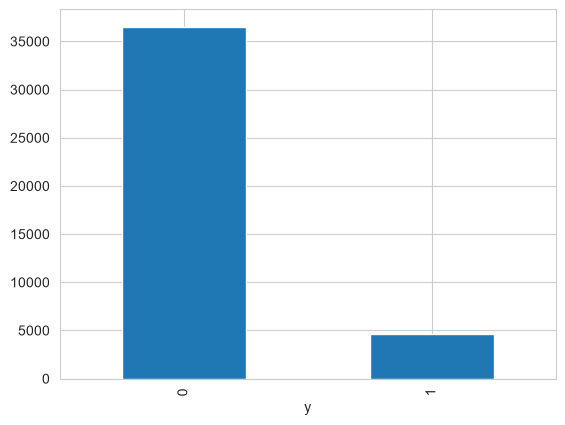

In [12]:
df['y'].value_counts().plot(kind='bar')

In [13]:
(df['y'].value_counts() / df.shape[0]) * 100

y
0    88.733728
1    11.266272
Name: count, dtype: float64

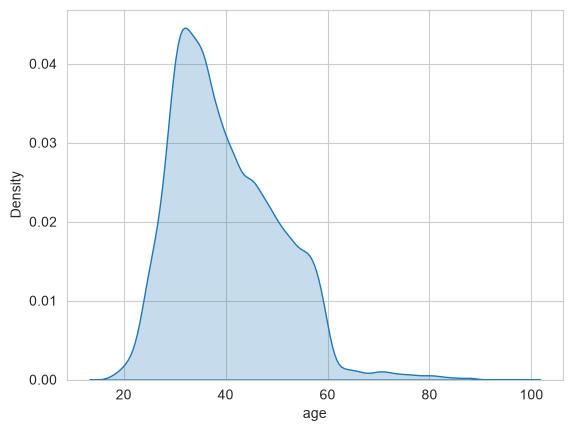

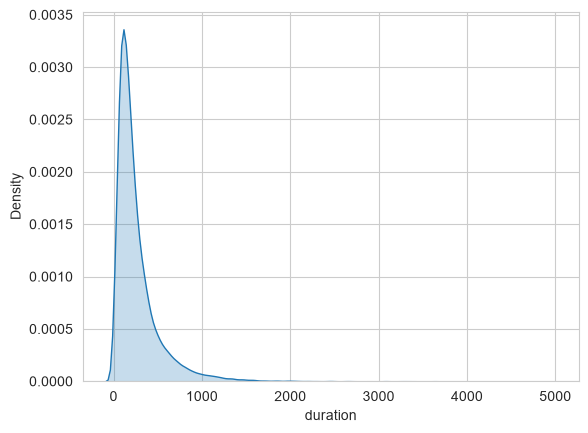

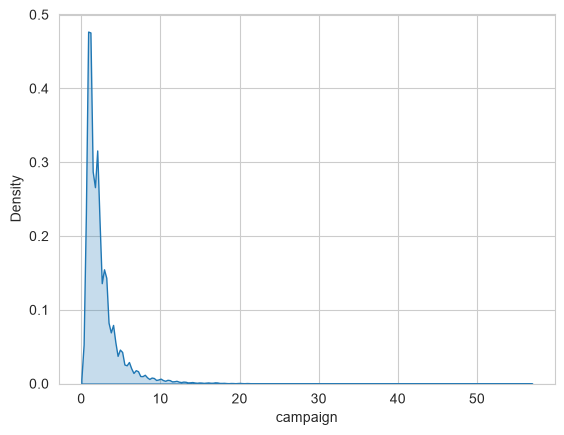

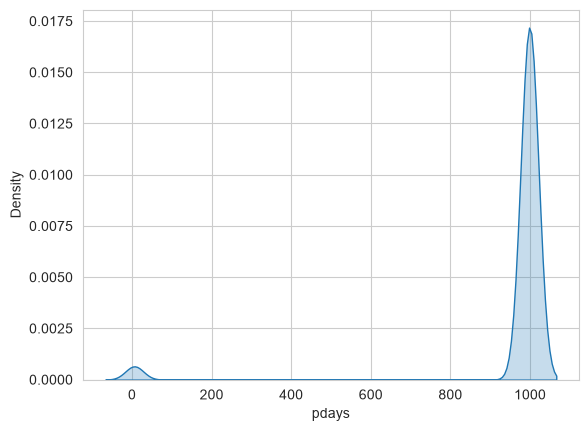

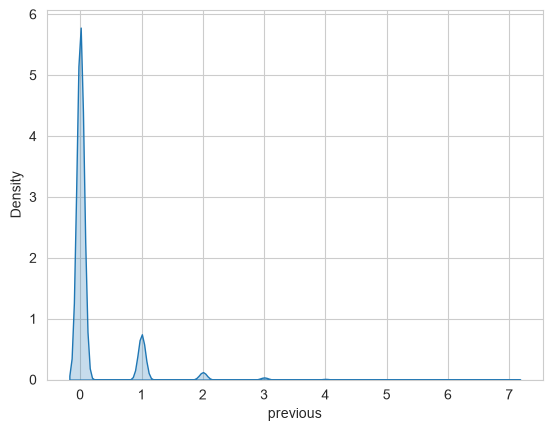

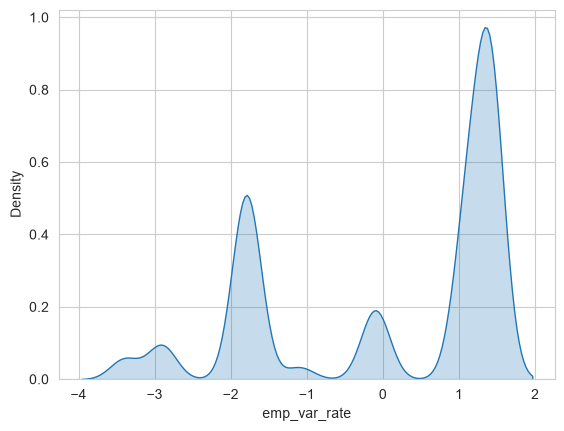

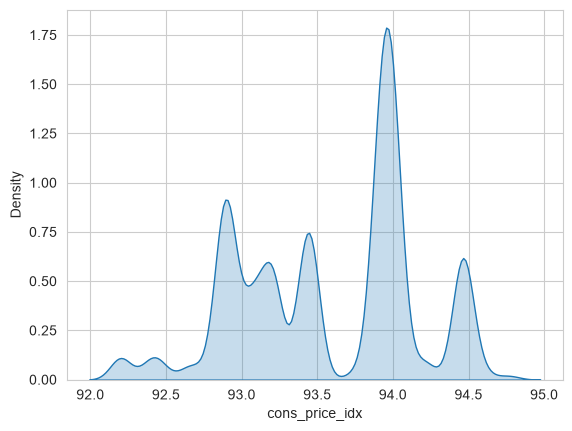

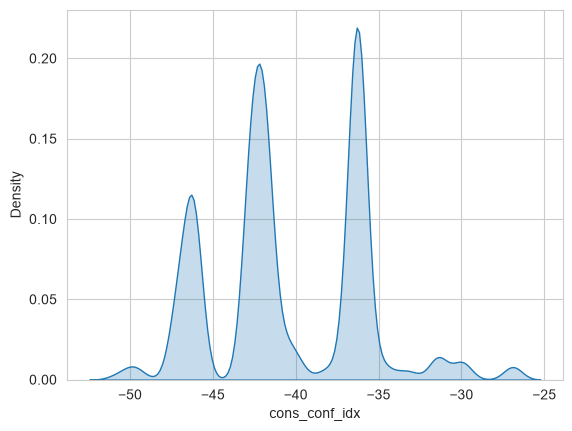

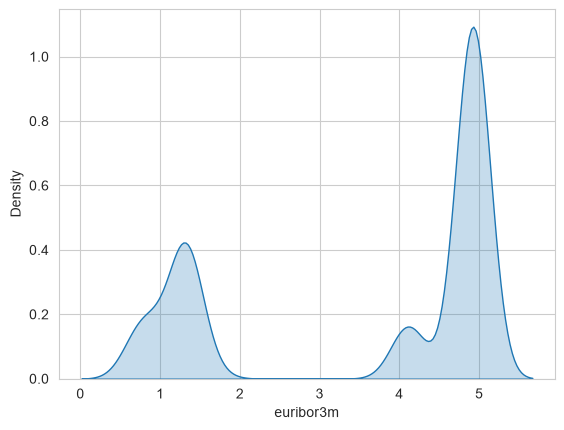

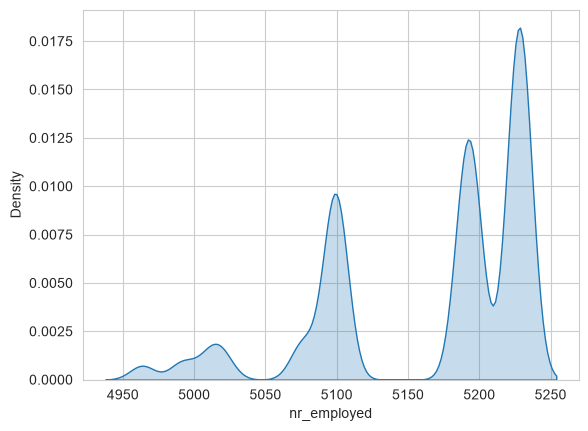

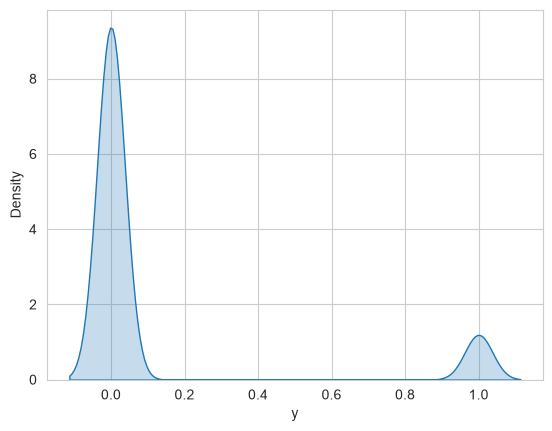

In [15]:
for col in num_col:
    sns.kdeplot(df[col], fill = True)
    plt.show()

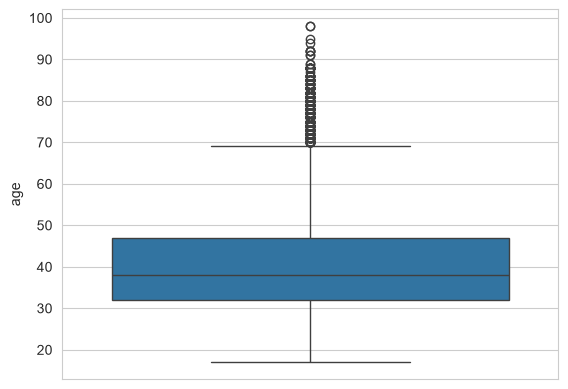

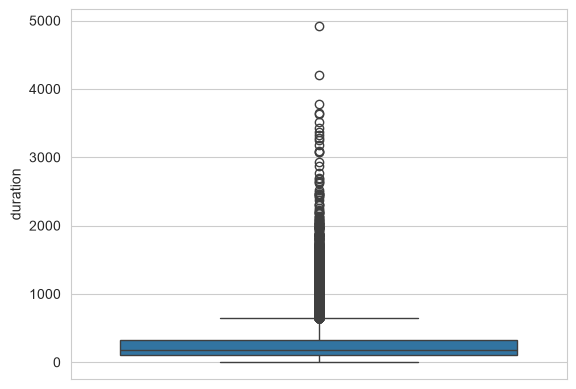

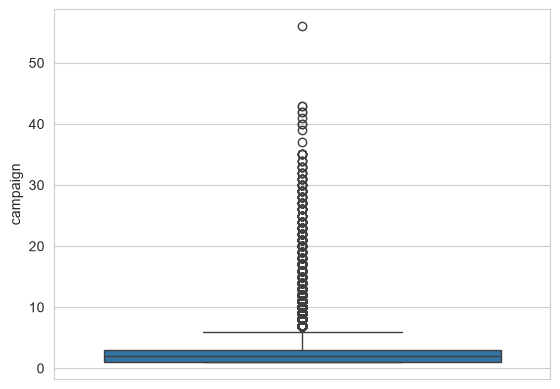

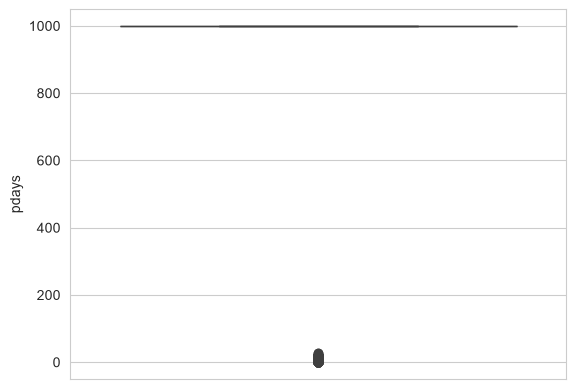

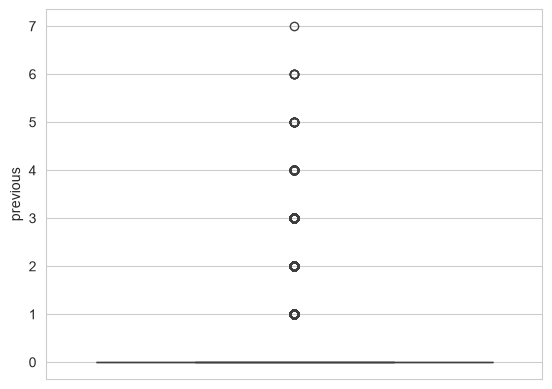

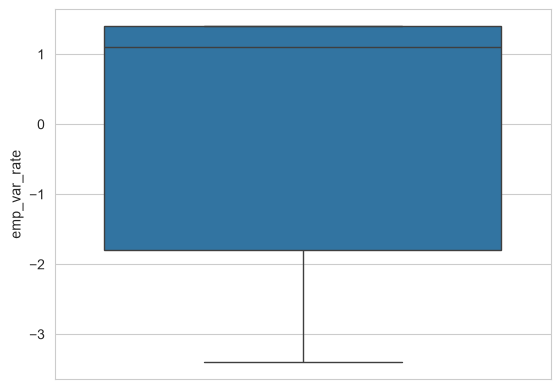

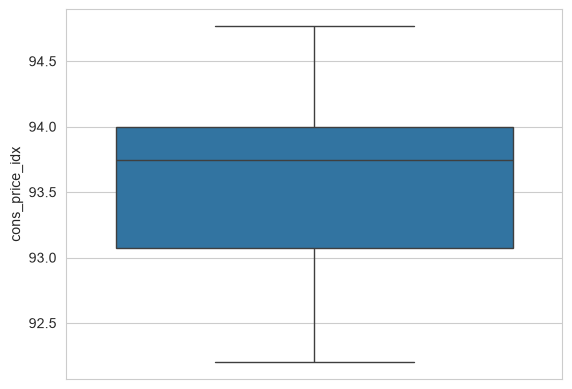

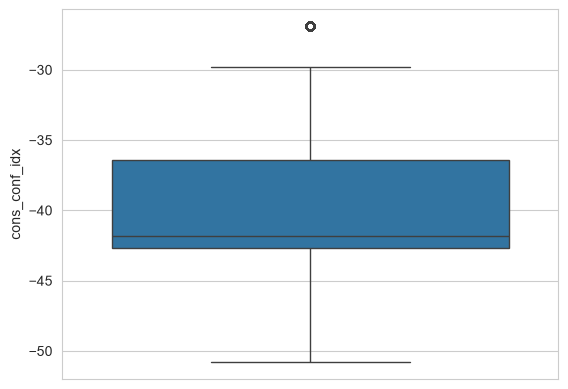

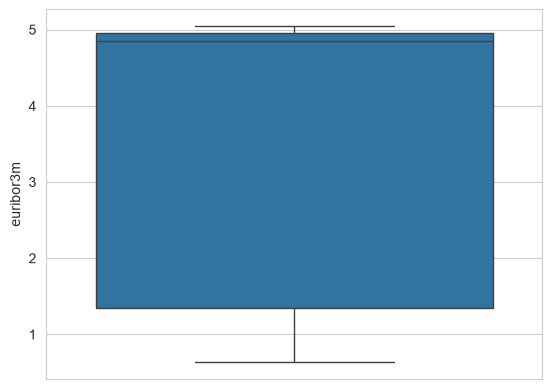

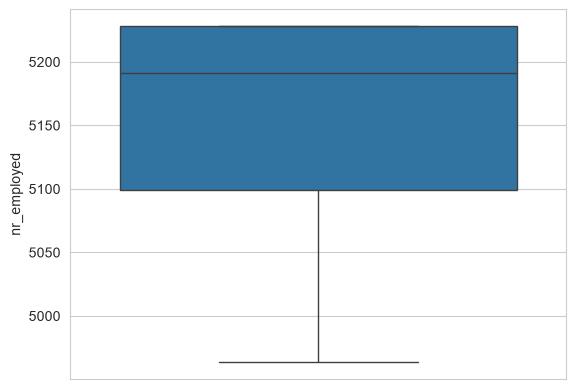

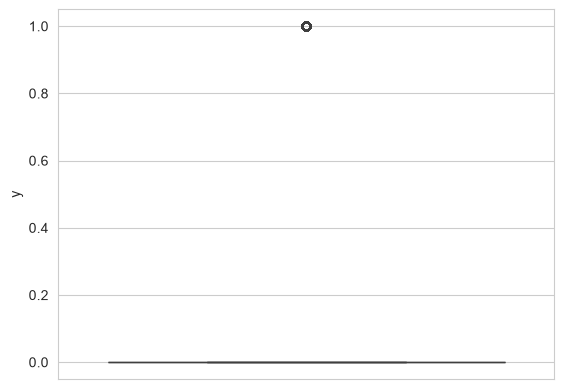

In [16]:
for col in num_col:
    sns.boxplot(df[col])
    plt.show()

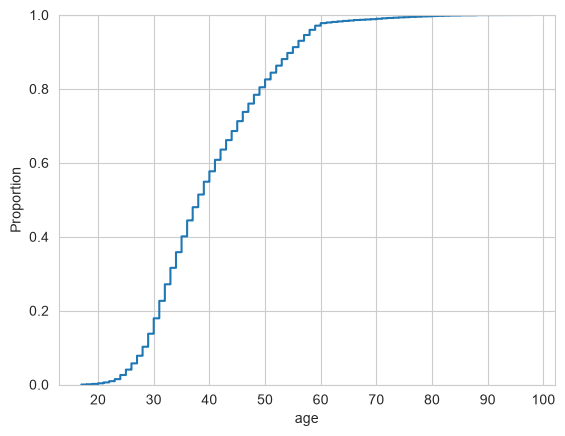

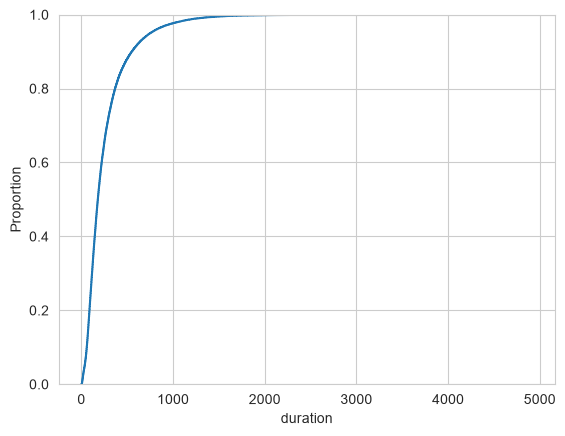

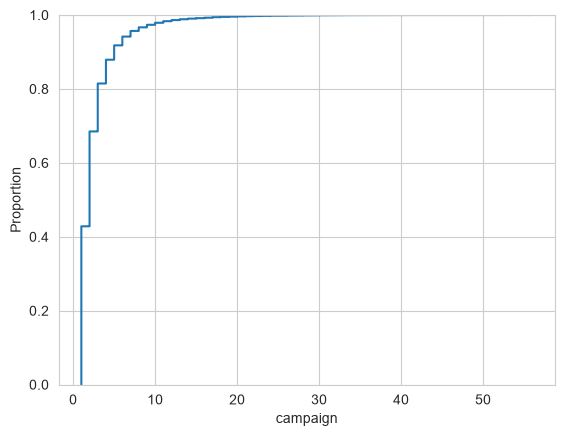

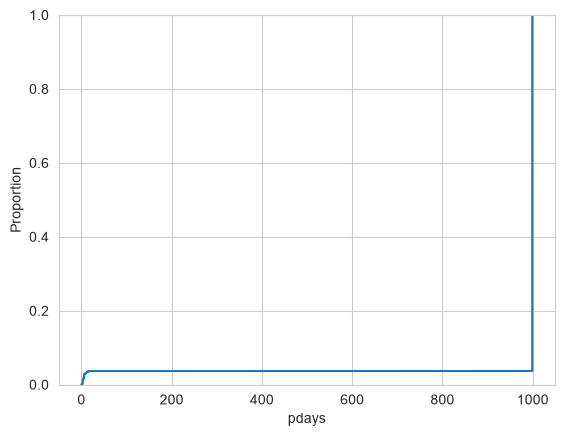

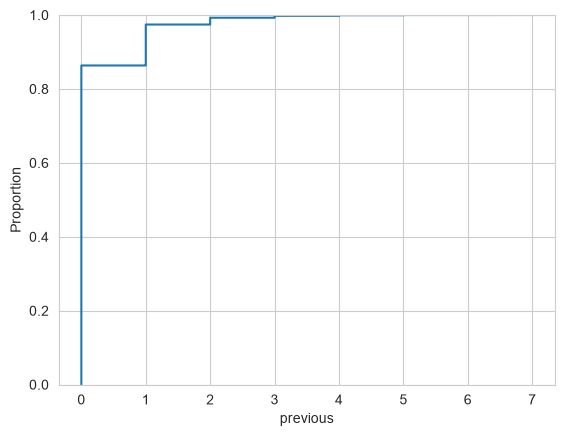

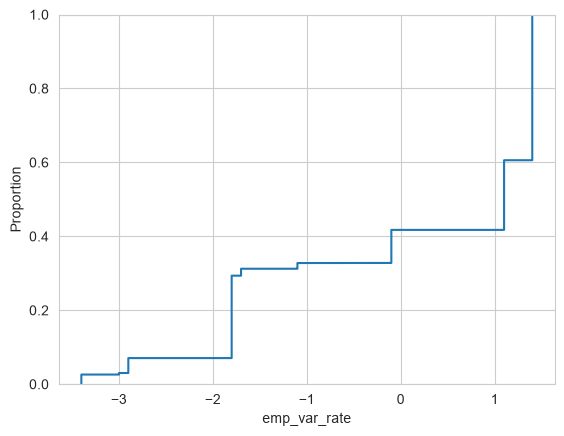

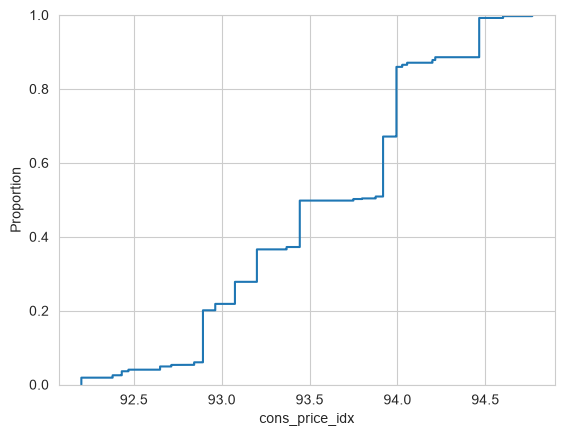

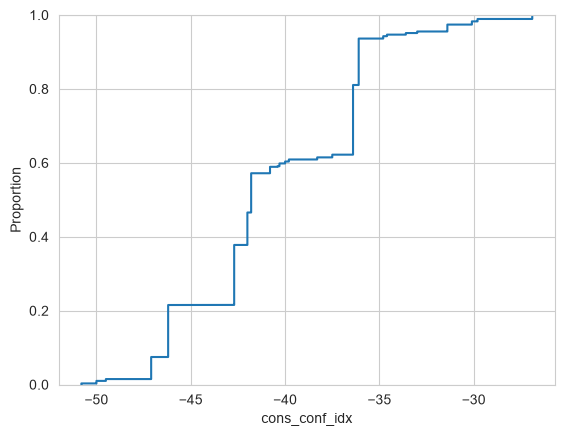

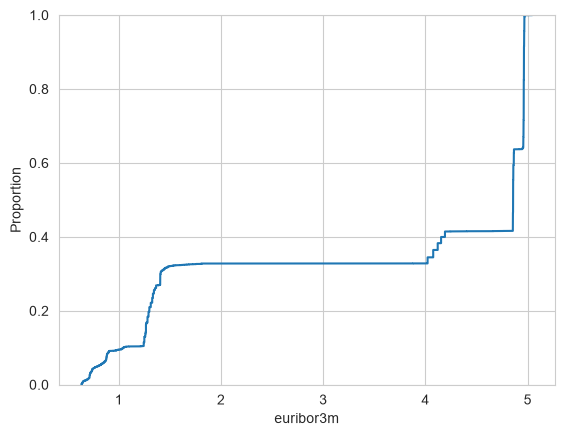

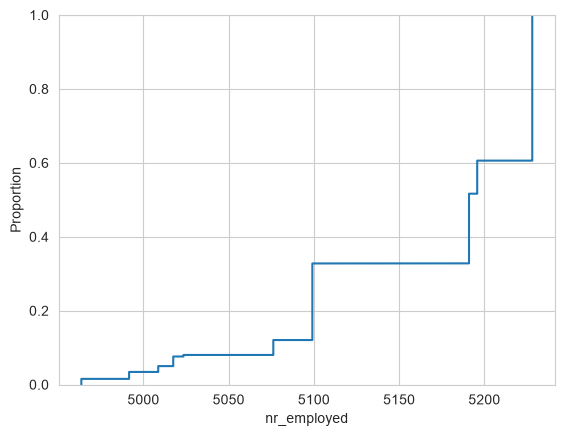

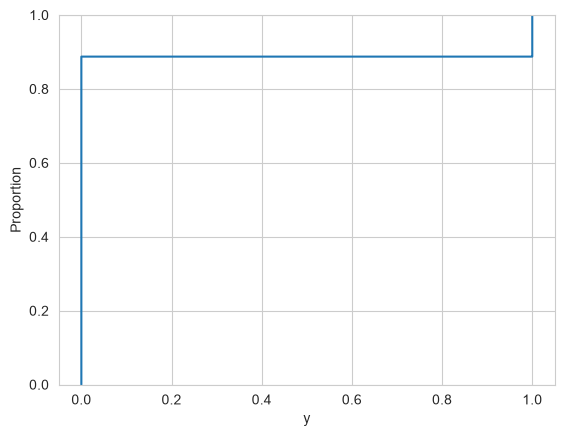

In [17]:
for col in num_col:
    sns.ecdfplot(df[col])
    plt.show()

In [19]:
str_col = list(df.select_dtypes(include= 'str').columns)
str_col

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome']

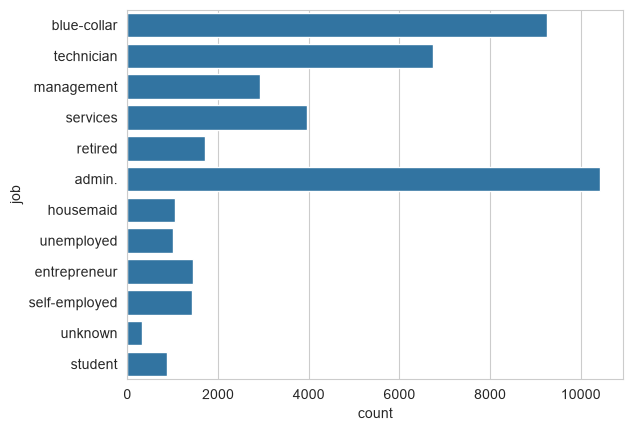

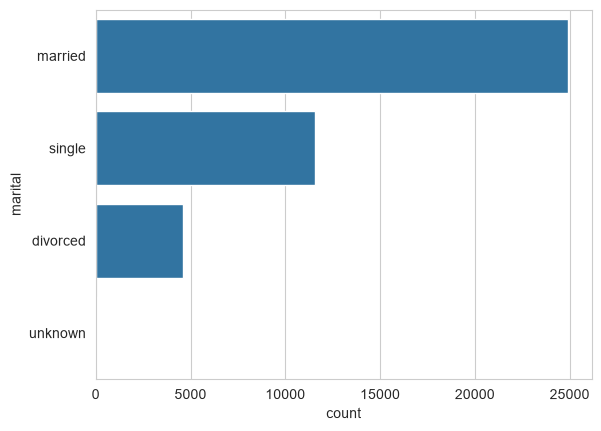

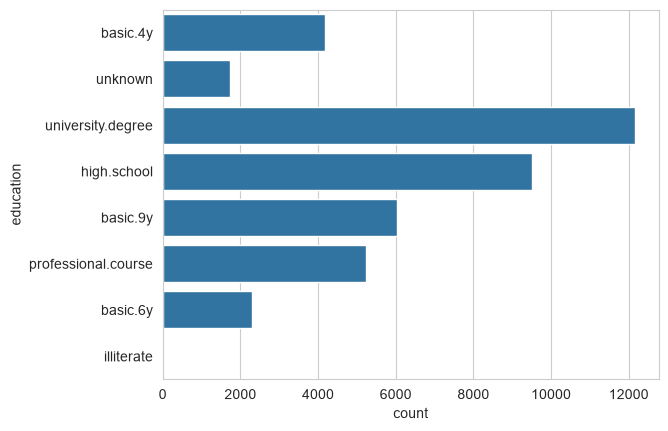

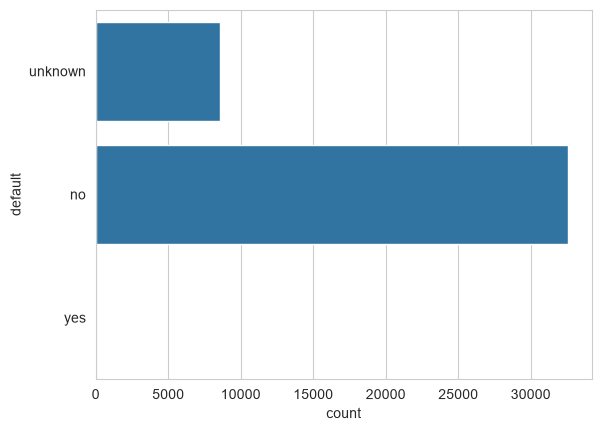

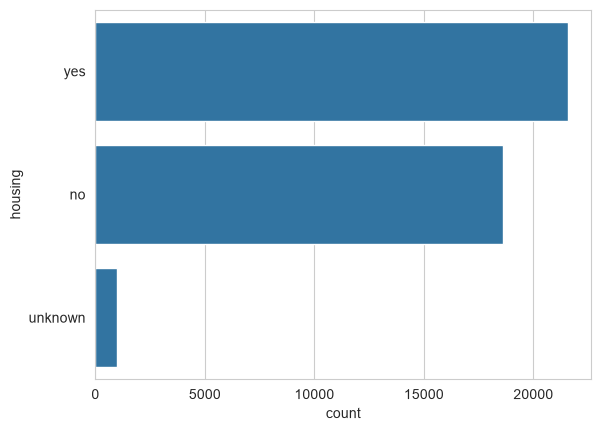

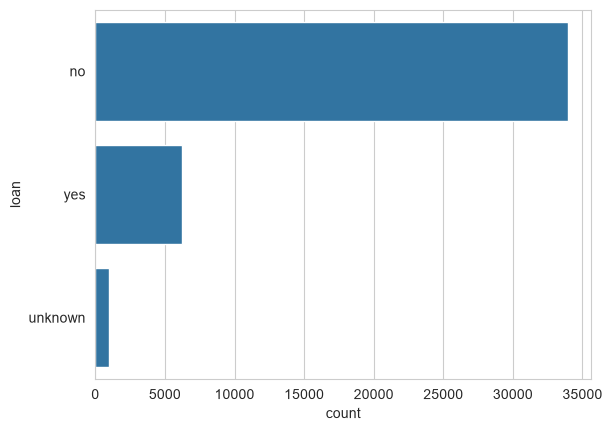

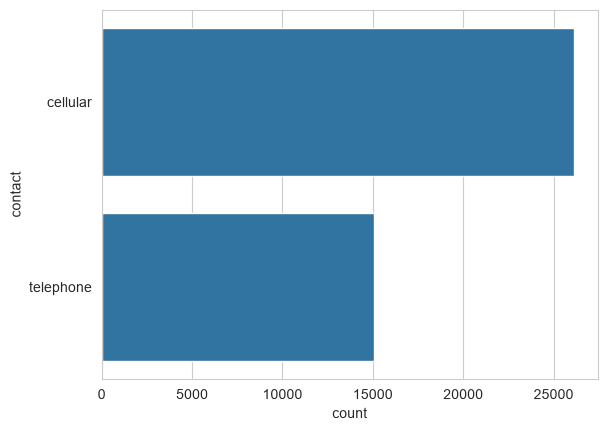

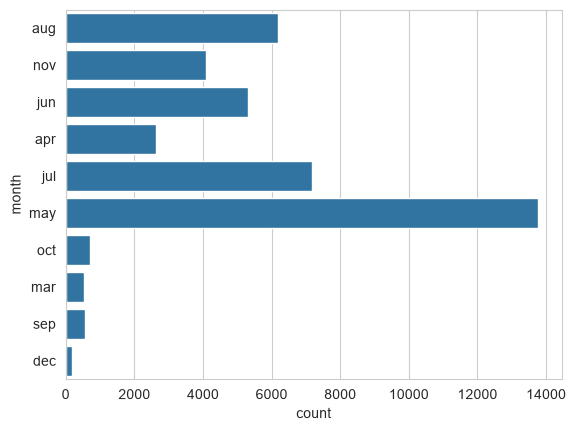

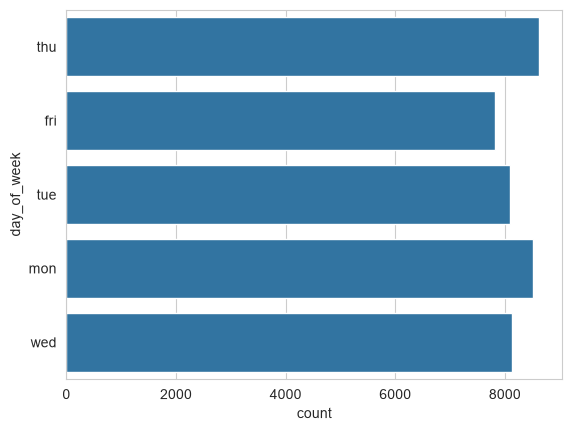

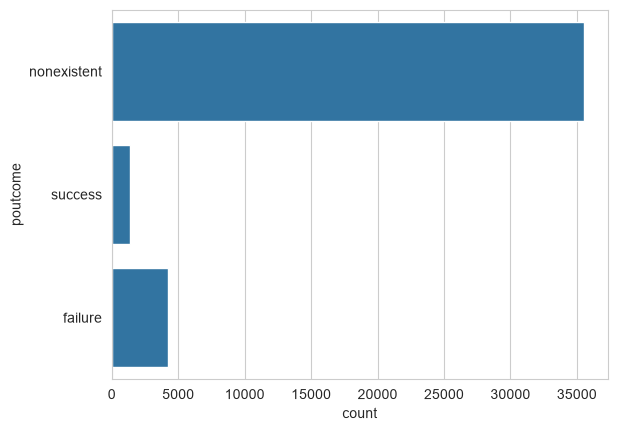

In [20]:
for col in str_col:
    sns.countplot(df[col])
    plt.show()

In [21]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='str')

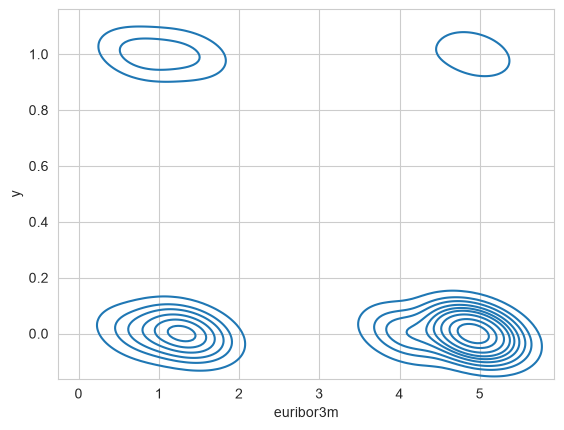

In [22]:
sns.kdeplot(x = 'euribor3m', y = 'y', data = df)
plt.show()

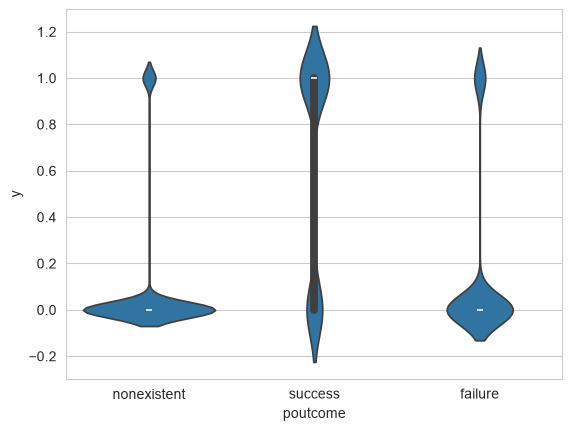

In [24]:
sns.violinplot(x= 'poutcome', y = 'y', data = df)
plt.show()

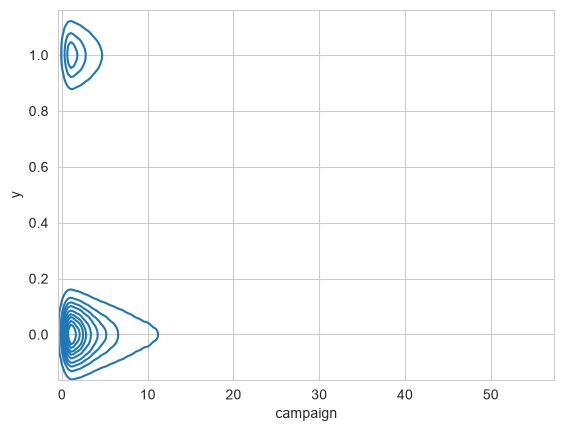

In [25]:
sns.kdeplot(x = 'campaign', y = 'y', data = df)
plt.show()

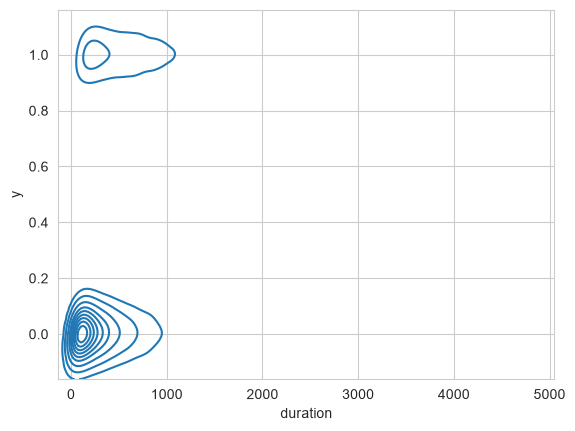

In [26]:
sns.kdeplot(x = 'duration', y = 'y', data = df)
plt.show()

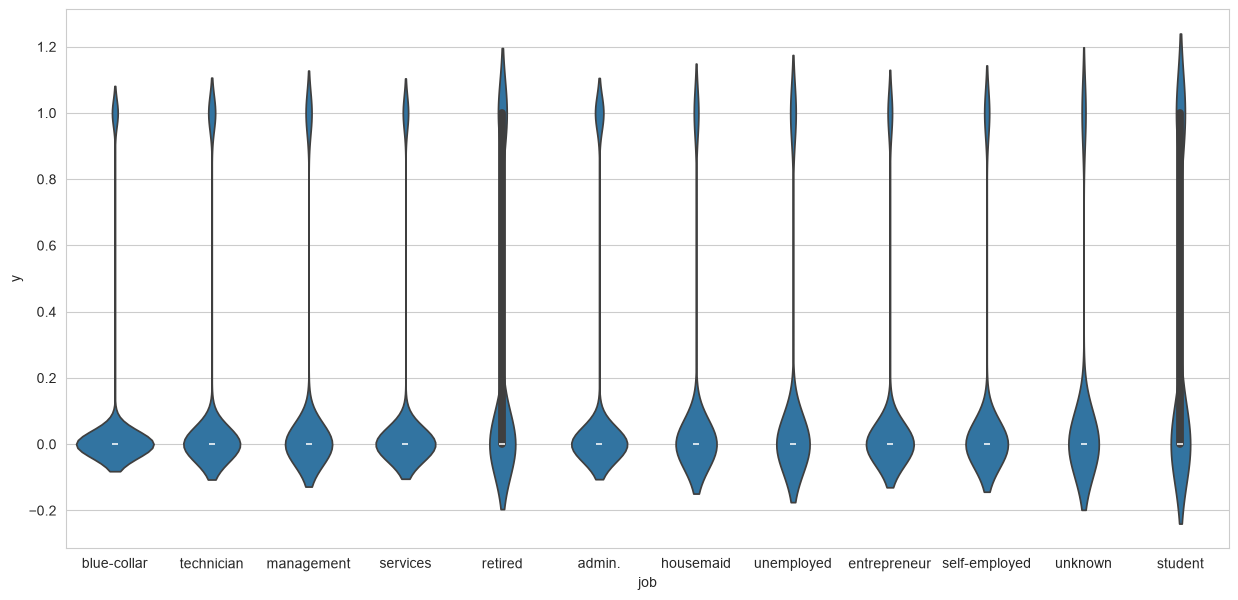

In [40]:
plt.figure(figsize=(15,7))
sns.violinplot(x= 'job', y = 'y', data = df)
plt.show()

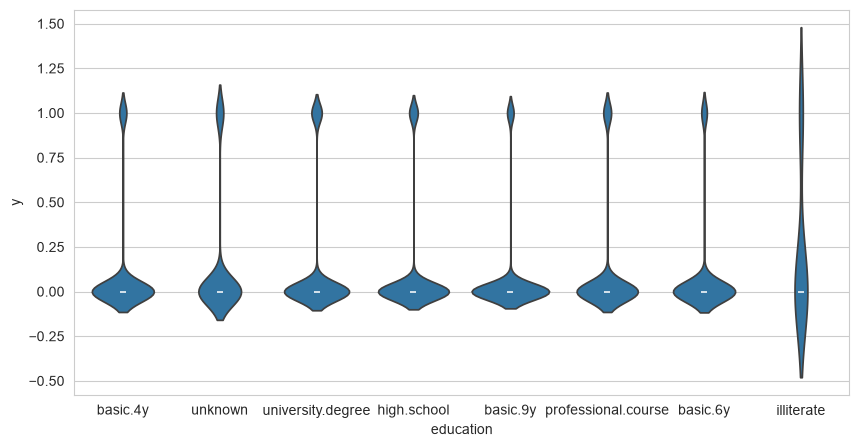

In [39]:
plt.figure(figsize=(10,5))
sns.violinplot(x= 'education', y = 'y', data = df)
plt.show()

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

df['previously_contacted'] = (df['pdays'] != 999).astype(int)
df['pdays_clean'] = df['pdays'].replace(999, -1)
df['contact_fatigue'] = (df['campaign'] >= 4).astype(int)
df['is_student_or_retired'] = df['job'].isin(['student', 'retired']).astype(int)

X = df.drop(columns=['y', 'duration', 'pdays'])
y = df['y']

num_cols = [
    'age', 'campaign', 'pdays_clean', 'previous',
    'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed'
]
cat_cols = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'day_of_week', 'poutcome'
]
passthrough_cols = ['previously_contacted', 'contact_fatigue', 'is_student_or_retired']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
        ('pass', 'passthrough', passthrough_cols)
    ],
    verbose_feature_names_out=False
).set_output(transform='pandas')

## LogisticRegression

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

baseline_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    baseline_pipe, X, y, cv=cv,
    scoring=['f1', 'roc_auc', 'recall', 'precision'],
    n_jobs=-1
)
print(f"Logistic Regression 5-Fold Mean F1:      {scores['test_f1'].mean():.4f}")
print(f"Logistic Regression 5-Fold Mean ROC-AUC: {scores['test_roc_auc'].mean():.4f}")
print(f"Logistic Regression 5-Fold Mean Recall:  {scores['test_recall'].mean():.4f}")
print(f"Logistic Regression 5-Fold Mean Precision: {scores['test_precision'].mean():.4f}")


Logistic Regression 5-Fold Mean F1:      0.4506
Logistic Regression 5-Fold Mean ROC-AUC: 0.7913
Logistic Regression 5-Fold Mean Recall:  0.6273
Logistic Regression 5-Fold Mean Precision: 0.3517


In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import RidgeClassifier


scale_weight = (len(y) - sum(y)) / sum(y)

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Ridge Classifier": RidgeClassifier(class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
    "LightGBM": LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_state=42),
    "XGBoost (GPU)": XGBClassifier(scale_pos_weight=scale_weight, device='cuda', tree_method='hist', eval_metric='logloss', random_state=42)
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Starting 5-Fold Stratified CV Benchmark...\n")

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring=['f1', 'roc_auc', 'recall', 'precision'],
        n_jobs=1 if 'cuda' in getattr(model, 'device', '') else -1
    )
    
    results.append({
        'Model': name,
        'Mean F1': scores['test_f1'].mean(),
        'Mean ROC-AUC': scores['test_roc_auc'].mean(),
        'Mean Recall': scores['test_recall'].mean(),
        'Mean Precision': scores['test_precision'].mean()
    })
    print(f"{name:<22} | F1: {scores['test_f1'].mean():.4f} | ROC-AUC: {scores['test_roc_auc'].mean():.4f}")

df_results = pd.DataFrame(results).sort_values(by='Mean ROC-AUC', ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print("FINAL DAY 3 MODEL BENCHMARK LEADERBOARD")
print("="*70)
print(df_results.to_string(index=False))


Starting 5-Fold Stratified CV Benchmark...

Logistic Regression    | F1: 0.4506 | ROC-AUC: 0.7913
Ridge Classifier       | F1: 0.4468 | ROC-AUC: 0.7906
Decision Tree          | F1: 0.4509 | ROC-AUC: 0.7719
Random Forest          | F1: 0.4874 | ROC-AUC: 0.8013
HistGradientBoosting   | F1: 0.4762 | ROC-AUC: 0.8029
LightGBM               | F1: 0.4751 | ROC-AUC: 0.8011
CatBoost               | F1: 0.4657 | ROC-AUC: 0.7923
XGBoost (GPU)          | F1: 0.4475 | ROC-AUC: 0.7766

FINAL DAY 3 MODEL BENCHMARK LEADERBOARD
               Model  Mean F1  Mean ROC-AUC  Mean Recall  Mean Precision
HistGradientBoosting 0.476189      0.802923     0.632033        0.382193
       Random Forest 0.487380      0.801330     0.611339        0.405315
            LightGBM 0.475076      0.801125     0.632033        0.380715
            CatBoost 0.465740      0.792309     0.620178        0.372965
 Logistic Regression 0.450584      0.791303     0.627290        0.351686
    Ridge Classifier 0.446817      0.790594  

In [47]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.inspection import permutation_importance
import numpy as np

param_dist = {
    'model__learning_rate': [0.02, 0.03, 0.05, 0.08, 0.1],
    'model__max_leaf_nodes': [15, 25, 31, 45, 63],
    'model__min_samples_leaf': [15, 20, 30, 50, 100],
    'model__l2_regularization': [0.0, 0.1, 1.0, 5.0, 10.0],
    'model__class_weight': ['balanced', None]
}

hgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', HistGradientBoostingClassifier(random_state=42))
])

print("Tuning HistGradientBoosting via RandomizedSearchCV (50 iterations)...")
search = RandomizedSearchCV(
    estimator=hgb_pipe,
    param_distributions=param_dist,
    n_iter=50,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
search.fit(X, y)

best_pipeline = search.best_estimator_
print(f"Best Tuned 5-Fold ROC-AUC: {search.best_score_:.4f}")
print("Best Parameters:", search.best_params_)

print("\nCalculating Out-of-Fold Probabilities for Threshold Optimization...")
y_oof_probs = cross_val_predict(best_pipeline, X, y, cv=cv, method='predict_proba')[:, 1]

thresholds = np.linspace(0.10, 0.90, 81)
f1_list, prec_list, rec_list = [], [], []

for t in thresholds:
    preds = (y_oof_probs >= t).astype(int)
    f1_list.append(f1_score(y, preds))
    prec_list.append(precision_score(y, preds, zero_division=0))
    rec_list.append(recall_score(y, preds))

best_idx = np.argmax(f1_list)
optimal_threshold = thresholds[best_idx]
print(f"\n" + "="*50)
print(f"OPTIMAL DECISION THRESHOLD:  = {optimal_threshold:.2f}")
print(f"At τ = {optimal_threshold:.2f}:")
print(f"  Max F1-Score: {f1_list[best_idx]:.4f}")
print(f"  Precision:    {prec_list[best_idx]:.4f}")
print(f"  Recall:       {rec_list[best_idx]:.4f}")
print("="*50)

print("\nComputing Permutation Feature Importance...")
perm_imp = permutation_importance(best_pipeline, X, y, n_repeats=5, random_state=42, n_jobs=-1)
sorted_idx = perm_imp.importances_mean.argsort()[::-1]

df_importance = pd.DataFrame({
    'Feature': X.columns[sorted_idx],
    'Importance Mean': perm_imp.importances_mean[sorted_idx]
})
print("\nTOP 10 MOST INFLUENTIAL FEATURES:")
print(df_importance.head(10).to_string(index=False))


Tuning HistGradientBoosting via RandomizedSearchCV (50 iterations)...
Best Tuned 5-Fold ROC-AUC: 0.8062
Best Parameters: {'model__min_samples_leaf': 50, 'model__max_leaf_nodes': 31, 'model__learning_rate': 0.05, 'model__l2_regularization': 0.1, 'model__class_weight': None}

Calculating Out-of-Fold Probabilities for Threshold Optimization...

OPTIMAL DECISION THRESHOLD:  = 0.23
At τ = 0.23:
  Max F1-Score: 0.5075
  Precision:    0.4595
  Recall:       0.5667

Computing Permutation Feature Importance...

TOP 10 MOST INFLUENTIAL FEATURES:
     Feature  Importance Mean
 nr_employed         0.014363
     contact         0.003274
emp_var_rate         0.002671
 pdays_clean         0.002487
       month         0.002356
    poutcome         0.002312
   euribor3m         0.002127
 day_of_week         0.001166
    campaign         0.001127
    previous         0.001044


In [46]:
from sklearn.feature_selection import SelectFromModel, SelectKBest, f_classif
from sklearn.ensemble import HistGradientBoostingClassifier

selector_pipe = Pipeline([
    ('prep', preprocessor),
    ('selector', SelectKBest(score_func=f_classif, k=25)), 
    ('model', HistGradientBoostingClassifier(
        min_samples_leaf=50,
        max_leaf_nodes=31,
        learning_rate=0.05,
        l2_regularization=0.1,
        random_state=42
    ))
])

sel_scores = cross_validate(
    selector_pipe, X, y, cv=cv,
    scoring=['roc_auc', 'f1', 'recall', 'precision'],
    n_jobs=-1
)

print(f"Top-K Feature Selected ROC-AUC: {sel_scores['test_roc_auc'].mean():.4f}")
print(f"Top-K Feature Selected F1:      {sel_scores['test_f1'].mean():.4f}")
print(f"Top-K Feature Selected Recall:  {sel_scores['test_recall'].mean():.4f}")
print(f"Top-K Feature Selected Precision: {sel_scores['test_precision'].mean():.4f}")

Top-K Feature Selected ROC-AUC: 0.8068
Top-K Feature Selected F1:      0.3668
Top-K Feature Selected Recall:  0.2537
Top-K Feature Selected Precision: 0.6625
